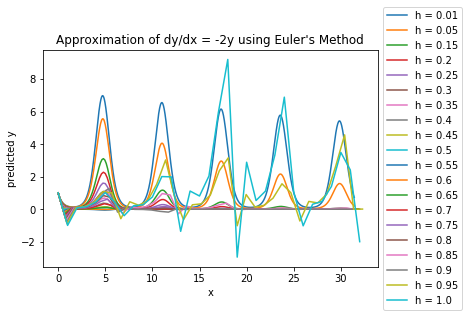

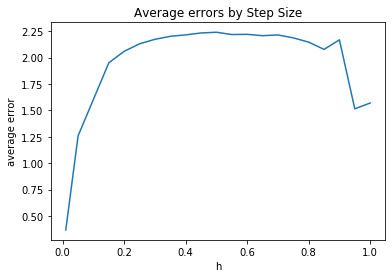

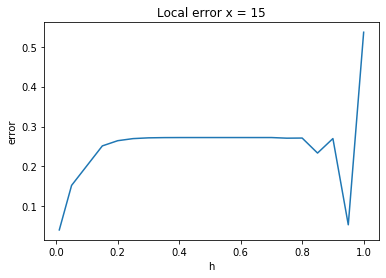

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Function representing dy/dx = -2y
def f(x, y):
    return ((-2 * y)*(np.cos(x)))

def exact(x):
    return np.exp(-2 * np.sin(x))
#Average Error between runs, sum up and average the y values
#Eulers method solve -2ycos(x)
#x(0,10pi)
#step size [.01, .05, .15, .2, .25 … 1]

h_list = np.array([0.01, 0.05, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1])


y_15_list = np.zeros(len(h_list))
avg_errors = np.zeros(len(h_list))

#Define base parameters
x_start, x_end = 0, 10*np.pi
    
for j in range(len(h_list)):
    h = h_list[j]

    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    y_values[0] = 1

    for i in range(len(x_values) - 1):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    errors = np.abs(y_values - exact(x_values))
    avg_errors[j] = np.mean(errors)

    idx_15 = np.argmin(np.abs(x_values - 15))
    y_15_list[j] = y_values[idx_15]

    plt.plot(x_values, y_values, label=f"h = {h}")
    
    idx_15 = np.argmin(np.abs(x_values - 15))
    y_15_list[j] = y_values[idx_15]
    
#pllotting
#Plot the different predicted y to step size
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel("x")
plt.ylabel("predicted y")
plt.show()

#plot the average errors by step size
plt.title("Average errors by Step Size")
plt.plot(h_list, avg_errors)
plt.xlabel("h")
plt.ylabel("average error")
plt.show()

#plot the local error at 15
y_exact_15 = exact(15)
y_15_errors = np.abs(y_15_list - y_exact_15)
plt.plot(h_list, y_15_errors)
plt.title("Local error x = 15")
plt.xlabel("h")
plt.ylabel("error")
plt.show()

Explanation to Part A: In general, smaller step sizes (h) lead to more accurate results. As h increases, the predicted y values begin to oscillate wildly and become unstable. While the average error usually grows as the step size gets larger, there is a noticeable "dip" in error when h gets close to 1.This happens because, with such a large step size, the method uses very few data points. With fewer points, there are fewer opportunities for errors to add up. Additionally, at h=1, the Euler method might "skip" over the waves of the function and accidentally land on a value close to the actual answer, making the error look lower than it actually is by pure coincidence.

Part B:

Yes, we can perform stability analysis on this equation. Unlike a basic system where the rate of change lambda is a constant number (like -2), this system has a lambda that changes based on x.Specifically, lambda = -2\cos(x). Because cos(x) moves between -1 and 1, our lambda oscillates between -2 and 2. This means the system is constantly switching between being stable and unstable. To keep the math stable, we use the condition:|1 + h(-2\cos(x))| < 1 Stability condition= ∣1+h(-2cox(x)∣<1